# Lecture 5 - Simple linear regression

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import statsmodels.api as sm # This contains the model fitting libraries for linear regression 
from statsmodels.graphics.tsaplots import plot_acf # autocorrelation function

#!pip install astsa
import astsa # You should have pip installed this for Lab 1.. if not, uncomment line above

# Set the random seed, this is so you will generate the same answers
# each time (for example, when generating white noise)
np.random.seed(42) 

First we'll start with a simple example where we have a linear trend plus noise. We'll take a sample from this function and try to fit a regression line to predict $y$ from $t$. 

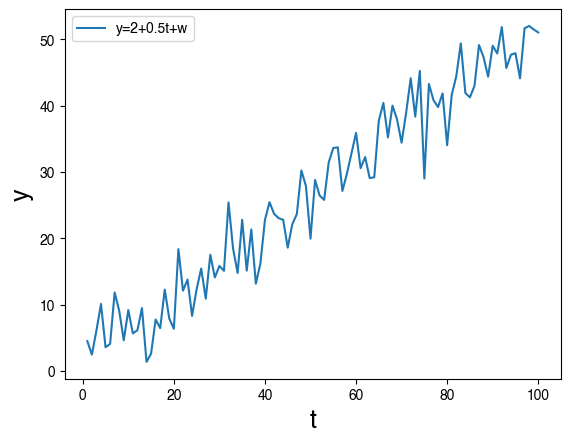

In [3]:
t = np.arange(1, 101)
sigma = 4 # If sigma=1, standard normal
y = 2 + 0.5*t + sigma*np.random.randn(len(t))

plt.plot(t,y,label='y=2+0.5t+w')
plt.xlabel('t',fontsize=18)
plt.ylabel('y',fontsize=18)
plt.legend()

We will fit the simple model

$$y_i = \beta_0 + \beta_1 t + \epsilon_i$$

using Ordinary Least Squares (OLS) in the `statsmodels` library.

In [4]:
linreg_simple = sm.OLS(y, t).fit()
print(linreg_simple.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.986
Model:                            OLS   Adj. R-squared (uncentered):              0.986
Method:                 Least Squares   F-statistic:                              6862.
Date:                Tue, 03 Feb 2026   Prob (F-statistic):                    3.01e-93
Time:                        19:51:25   Log-Likelihood:                         -271.87
No. Observations:                 100   AIC:                                      545.7
Df Residuals:                      99   BIC:                                      548.3
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

We can see that our regression recovered the coefficient $x1=0.5286$, which is pretty close to our true $\beta_1=0.5$, but it's not quite right because we didn't get the intercept $\beta_0$. When we show the fitted line, we can see that the best fit line should be shifted up.

Text(0, 0.5, 'y')

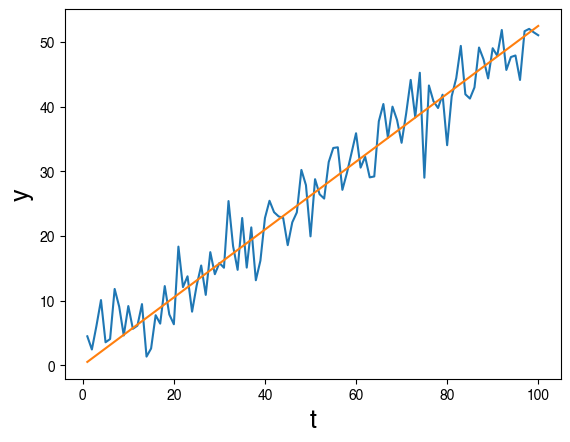

In [5]:
plt.plot(t,y)
plt.plot(t,linreg_simple.fittedvalues)
plt.xlabel('t',fontsize=18)
plt.ylabel('y',fontsize=18)

We can fix this by adding a constant term to our OLS fit, as follows:

In [6]:
T = sm.add_constant(t)
linreg_simple2 = sm.OLS(y, T).fit()
print(linreg_simple2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                     1601.
Date:                Tue, 03 Feb 2026   Prob (F-statistic):           1.62e-62
Time:                        19:51:25   Log-Likelihood:                -270.29
No. Observations:                 100   AIC:                             544.6
Df Residuals:                      98   BIC:                             549.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3032      0.735      1.773      0.0

We can also report the confidence intervals on our estimates of $\beta_0$ and $\beta_1$, which can be useful for determining our certainty of these estimates.

In [7]:
ci_linreg_simple2 = linreg_simple2.conf_int(alpha=0.05)
print(ci_linreg_simple2)
print(f'95% confidence interval for B0$: [{ci_linreg_simple2[0,0]:.3f}, {ci_linreg_simple2[0,1]:.3f}]')
print(f'95% confidence interval for B1$: [{ci_linreg_simple2[1,0]:.3f}, {ci_linreg_simple2[1,1]:.3f}]')

[[-0.15543644  2.76178753]
 [ 0.48049713  0.53064895]]
95% confidence interval for B0$: [-0.155, 2.762]
95% confidence interval for B1$: [0.480, 0.531]


Text(0, 0.5, 'y')

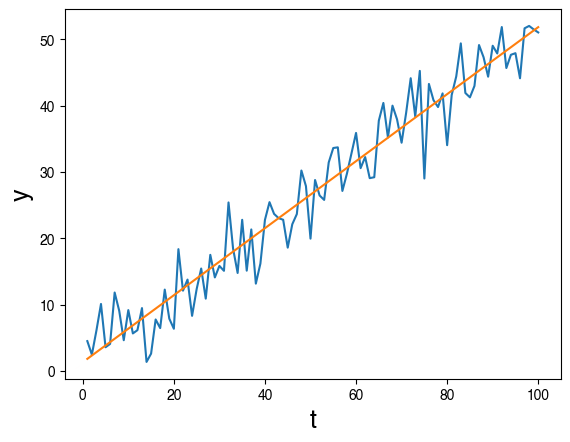

In [8]:
plt.plot(t,y)
plt.plot(t,linreg_simple2.fittedvalues)
plt.xlabel('t',fontsize=18)
plt.ylabel('y',fontsize=18)

For time series, one thing we want to check is that our residuals (the difference between the predicted data and our actual value) are weakly stationary, which allows us to assume that our error $\epsilon_t$ is weakly stationary. 

We can do that by plotting the residuals over time as well as the autocorrelation function of the residuals. How does this look? 

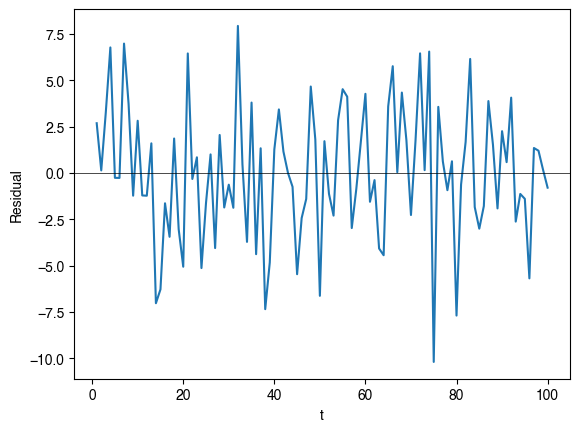

<Figure size 1000x500 with 0 Axes>

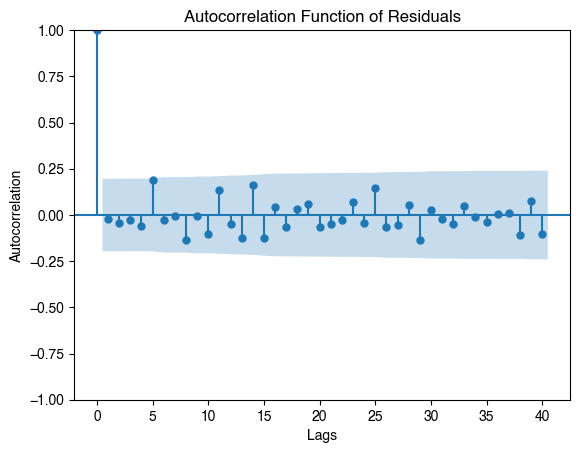

In [9]:
residuals = linreg_simple2.resid

plt.figure()
plt.plot(t,residuals)
plt.axhline(0, color='k', linewidth=0.5) # Horizontal line at 0
plt.xlabel('t')
plt.ylabel('Residual')

plt.figure(figsize=(10, 5))
plot_acf(residuals, lags=40, title='Autocorrelation Function of Residuals')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()

## Another (messier) example

Now let's load some data from `astsa`, for example, the price of chicken over time, from 2001 to 2016. As pointed out in your book, commodities (such as raw materials, basic resources, agricultural, or mining products) show specific fluctuations in their prices over time. For this example, we'll fit a regression model for chicken prices as our response $y$ and time as our predictor $x$.

In [10]:
chicken_data = astsa.load_chicken()
print(chicken_data)

        Time   Value
0    2001-08   65.58
1    2001-09   66.48
2    2001-10   65.70
3    2001-11   64.33
4    2001-12   63.23
..       ...     ...
175  2016-03  111.56
176  2016-04  111.55
177  2016-05  111.98
178  2016-06  111.84
179  2016-07  111.46

[180 rows x 2 columns]


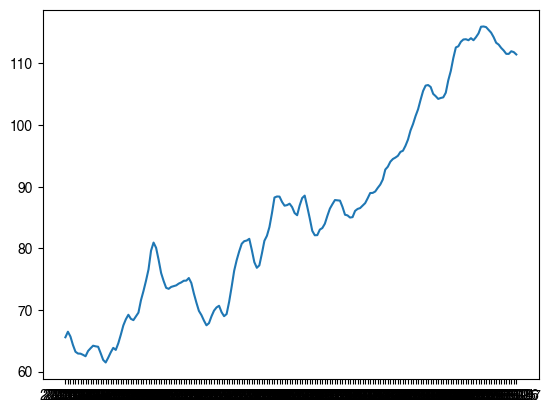

In [11]:
plt.plot(chicken_data['Time'], chicken_data['Value'])

In [12]:
chicken_data['Time'] = pd.to_datetime(chicken_data['Time'])
chicken_data.set_index('Time', inplace=True)
print(chicken_data)

             Value
Time              
2001-08-01   65.58
2001-09-01   66.48
2001-10-01   65.70
2001-11-01   64.33
2001-12-01   63.23
...            ...
2016-03-01  111.56
2016-04-01  111.55
2016-05-01  111.98
2016-06-01  111.84
2016-07-01  111.46

[180 rows x 1 columns]


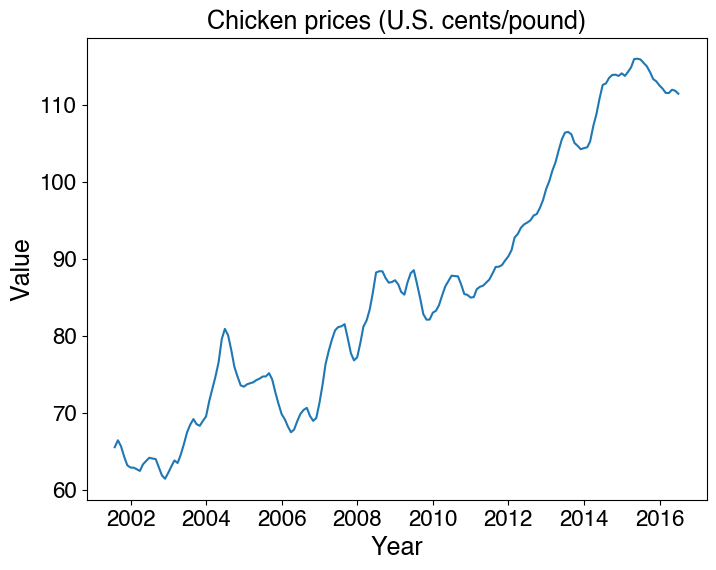

In [13]:
plt.figure(figsize=(8,6))
plt.plot(chicken_data.index, chicken_data['Value'], label='Value')
plt.xlabel('Year', fontsize=18)
plt.ylabel('Value', fontsize=18)
plt.title('Chicken prices (U.S. cents/pound)', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16);

## Chicken price regression

We will fit a linear regression model to the chicken price data using time as the covariate. Here, the model is:

$$y_i = \beta_0 + \beta_1 x_i + \epsilon_i$$

where $y_i$ is the price of chicken at time index $i$, and $x_i = i$. We can interpret the coefficient $\beta_1$ as the numerical change in price of chicken from one month to the next (since each time step is in one month). From just looking at the graph, we know that the linear fit is likely not the best model for these data, since there are also underlying (potentially seasonal) fluctuations in the data. Still, we may be interested in the overall trend in price increases for this commodity.

We can then use statsmodels to fit the OLS solution for the line of best fit to the data. 

In [14]:
yvec = np.array(chicken_data['Value'])
n = len(yvec) # number of time points
xvec = np.arange(1, n+1)
linreg = sm.OLS(yvec, xvec).fit()
print(linreg.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.885
Model:                            OLS   Adj. R-squared (uncentered):              0.885
Method:                 Least Squares   F-statistic:                              1381.
Date:                Tue, 03 Feb 2026   Prob (F-statistic):                    4.53e-86
Time:                        19:51:26   Log-Likelihood:                         -864.85
No. Observations:                 180   AIC:                                      1732.
Df Residuals:                     179   BIC:                                      1735.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

Here, notice that in the table only one coefficient, $x1$ is reported. This is because we have not actually fit the model $y_i = \beta_0 + \beta_1 x_i + \epsilon_i$. Instead, we have fit the model without an intercept: $y_i = \beta_1 x_1$. If we do want to include a $\beta_0$ term, we need to add a constant to our model.

In [15]:
X = sm.add_constant(xvec)
print(X)

[[  1.   1.]
 [  1.   2.]
 [  1.   3.]
 [  1.   4.]
 [  1.   5.]
 [  1.   6.]
 [  1.   7.]
 [  1.   8.]
 [  1.   9.]
 [  1.  10.]
 [  1.  11.]
 [  1.  12.]
 [  1.  13.]
 [  1.  14.]
 [  1.  15.]
 [  1.  16.]
 [  1.  17.]
 [  1.  18.]
 [  1.  19.]
 [  1.  20.]
 [  1.  21.]
 [  1.  22.]
 [  1.  23.]
 [  1.  24.]
 [  1.  25.]
 [  1.  26.]
 [  1.  27.]
 [  1.  28.]
 [  1.  29.]
 [  1.  30.]
 [  1.  31.]
 [  1.  32.]
 [  1.  33.]
 [  1.  34.]
 [  1.  35.]
 [  1.  36.]
 [  1.  37.]
 [  1.  38.]
 [  1.  39.]
 [  1.  40.]
 [  1.  41.]
 [  1.  42.]
 [  1.  43.]
 [  1.  44.]
 [  1.  45.]
 [  1.  46.]
 [  1.  47.]
 [  1.  48.]
 [  1.  49.]
 [  1.  50.]
 [  1.  51.]
 [  1.  52.]
 [  1.  53.]
 [  1.  54.]
 [  1.  55.]
 [  1.  56.]
 [  1.  57.]
 [  1.  58.]
 [  1.  59.]
 [  1.  60.]
 [  1.  61.]
 [  1.  62.]
 [  1.  63.]
 [  1.  64.]
 [  1.  65.]
 [  1.  66.]
 [  1.  67.]
 [  1.  68.]
 [  1.  69.]
 [  1.  70.]
 [  1.  71.]
 [  1.  72.]
 [  1.  73.]
 [  1.  74.]
 [  1.  75.]
 [  1.  76.]
 [  1.  77.]

In [16]:
linreg2 = sm.OLS(yvec, X).fit()
print(linreg2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.917
Model:                            OLS   Adj. R-squared:                  0.917
Method:                 Least Squares   F-statistic:                     1974.
Date:                Tue, 03 Feb 2026   Prob (F-statistic):           2.83e-98
Time:                        19:51:28   Log-Likelihood:                -532.83
No. Observations:                 180   AIC:                             1070.
Df Residuals:                     178   BIC:                             1076.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         58.5832      0.703     83.331      0.0

Now we have an estimate of $\beta_0 = 58.5832$ and an estimate of $\beta_1=0.2993$. What this means is that the price of chicken is going up by approximately 0.30 cents per pound per month, and had started at a base price of 58.5 cents per pound.

We can also calculate the confidence intervals to understand the uncertainty associated with the estimate.

In [17]:
ci_linreg2 = linreg2.conf_int(alpha=0.05)
print(ci_linreg2)
print(f'95% confidence interval for price fluctuation: [{ci_linreg2[1,0]:.2f}, {ci_linreg2[1,1]:.2f}]')

[[57.19590866 59.97056185]
 [ 0.28604822  0.31263657]]
95% confidence interval for price fluctuation: [0.29, 0.31]


Now let's plot the regression line on the original data.

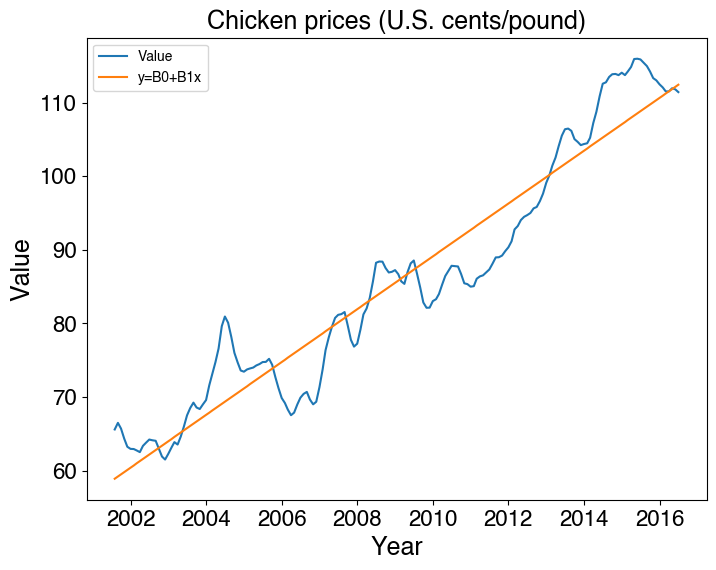

In [18]:
plt.figure(figsize=(8,6))
plt.plot(chicken_data.index, chicken_data['Value'], label='Value')
plt.plot(chicken_data.index, linreg2.fittedvalues, label='y=B0+B1x')
#plt.plot(chicken_data.index, linreg.fittedvalues, label='No B0')
plt.xlabel('Year', fontsize=18)
plt.ylabel('Value', fontsize=18)
plt.title('Chicken prices (U.S. cents/pound)', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16);
plt.legend()

What are some problems with this? Do our residuals show any strong or unmodeled dependence on time?

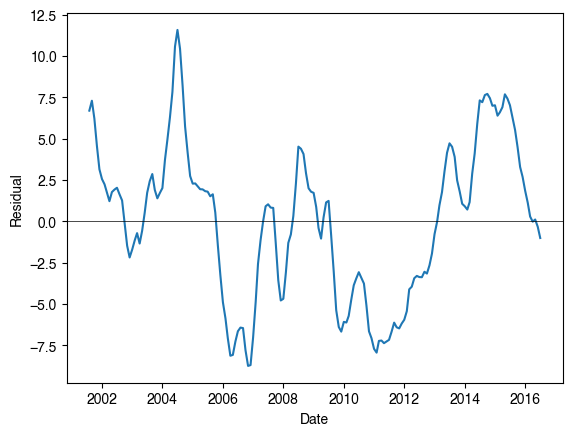

<Figure size 1000x500 with 0 Axes>

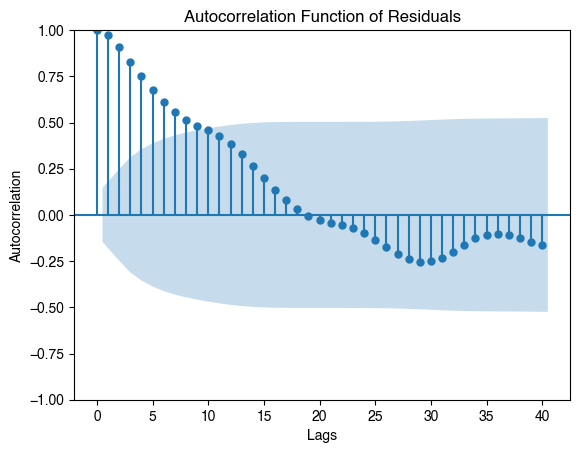

In [19]:
residuals = linreg2.resid

plt.figure()
plt.plot(chicken_data.index,residuals)
plt.axhline(0, color='k', linewidth=0.5) # Horizontal line at 0
plt.xlabel('Date')
plt.ylabel('Residual')

plt.figure(figsize=(10, 5))
plot_acf(residuals, lags=40, title='Autocorrelation Function of Residuals')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()